# Week 11 - Neural Networks (solution)

Solution author: Lukas Hedegaard (lh@eng.au.dk)

Learning contents:
- Convolutional Neural Network
    - Implement the LeNet-5 inspired architecture in PyTorch
- Limited labelled data
    - Rerun the LeNet-5 network with only 100 examples total
- Implement an Autoencoder and train it on the unlabelled data
- Demo: Using the Autoencoder in a multi-task learning setup to improve classification performance.

In [1]:
import numpy as np  # initialize NumPy/OpenMP before PyTorch in Jupyter
import torch
from math import ceil
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torch.optim import SGD
from torch import tanh, flatten
from torch.utils.data import DataLoader, random_split
from torch.nn import Conv2d, AvgPool2d, Linear, Module, ConvTranspose2d, Upsample, Tanh, Sequential
from torch.nn.functional import log_softmax, nll_loss, mse_loss

torch.manual_seed(42)


**Expected runtime:** approximately 30–60 minutes for the full notebook on a modern CPU.
Section 1 (10 epochs, full MNIST) is the main bottleneck (~15–20 min on CPU).
GPU (MPS on Apple Silicon, or CUDA on NVIDIA) will reduce total runtime to under 5 minutes.
You can reduce `epochs` in training cells to explore faster — the network converges quickly.

# Dataset
We'll be using the MNIST dataset again this time:

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST('../data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('../data', train=False, download=True, transform=transform)

train_loader = DataLoader(
    train_data,
    batch_size = 64,
    shuffle=True,
)

test_loader = DataLoader(
    test_data,
    batch_size = 64,
)

In [3]:
data, targets = next(iter(train_loader))
data.shape, targets.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

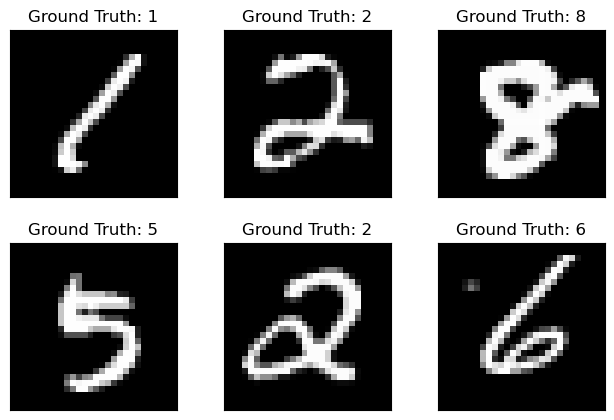

In [4]:
fig = plt.figure()
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.tight_layout()
    plt.imshow(data[i][0], cmap='gray', interpolation='none')
    plt.title("Ground Truth: {}".format(targets[i]))
    plt.xticks([])
    plt.yticks([])

## 1) Convolutional Neural Network
In this exercise, we will implement a Convolutional Neural Network inspired by the LeNet-5 architecture.

![](lenet.png)
Source: http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf

Unlike the original architecture, for the subsampling we will use Average Pooling, and our output layer will be another Linear layer.

_Note: CNNs are covered in Lecture 22 (the second lecture of Week 11); autoencoders (Section 3) are from Lecture 21._

## 1.1) Implement the LeNet-5 inspired architecture in PyTorch
The architecture should consist of the following layers:
- Convolutional layer with  6 neurons, a 5x5 kernel, and stride 1, followed by a tanh function
- Average pooling layer with a 2x2 window size
- Convolutional layer with 16 neurons, a 5x5 kernel, and stride 1, followed by a tanh function
- Average pooling layer with a 2x2 window size
- Fully connected layer with 120 neurons, followed by a tanh function
- Fully connected layer with 84 neurons, followed by a tanh function
- Fully connected (output) layer with 10 neurons (one per class), followed by a tanh function — the provided skeleton then applies `log_softmax` to turn these into log-probabilities

**Note:** MNIST images are 28×28, not 32×32 as shown in the `lenet.png` figure above. You must compute the correct `in_features` for the first fully-connected layer from the output shapes of the two Conv+Pool blocks. Hint: trace the spatial dimension H through (28→24→12→8→4).

In [5]:
class LeNet5(Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1)
        self.conv2 = Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1)
        self.subsample = AvgPool2d(kernel_size=(2,2), stride=2)
        self.fc1 = Linear(in_features=256, out_features=120)
        self.fc2 = Linear(in_features=120, out_features=84)
        self.fc3 = Linear(in_features=84, out_features=10)

    def forward(self, x):
        x = tanh(self.conv1(x))
        x = self.subsample(x)
        x = tanh(self.conv2(x))
        x = self.subsample(x)
        x = flatten(x, 1)
        x = tanh(self.fc1(x))
        x = tanh(self.fc2(x))
        x = tanh(self.fc3(x))
        return log_softmax(x, dim=1)

    
def train(
    model:Module, 
    train_loader:DataLoader, 
    optimizer: SGD, 
    epoch:int, 
    log_interval = 50
):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        # Reset the gradients
        optimizer.zero_grad() 
        
        # Feed the data through the model
        output = model(data) 
        
        # Compute the negative log-likelihood loss
        loss = nll_loss(output, target) 
        
        # Backward propagate the gradients
        loss.backward() 
        
        # Perform an update step using the optimizer
        optimizer.step() 
        
        # Log
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))


def test(model:Module, test_loader:DataLoader):
    # Set model to evaluation mode
    model.eval()
    
    test_loss = 0
    correct = 0
    
    # Don't accumulate gradients
    with torch.no_grad():
        for data, target in test_loader:
            # Feed the data through the model
            output = model(data)
            
            # Sum up batch loss
            test_loss += nll_loss(output, target, reduction='sum').item()  
            
            # The prediction is the index of the max log-probability
            pred = output.argmax(dim=1, keepdim=True)  
            
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.3f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)
    ))

Train the network for 10 epochs using SGD with a `learning_rate = 0.01` and `momentum = 0.9`.
You should be able to get a 99% accuracy.

In [6]:
model = LeNet5()
optimizer = SGD(model.parameters(), lr=0.01, momentum=0.9)

epochs = 10
for epoch in range(1, epochs + 1):
    train(model, train_loader, optimizer, epoch, log_interval=50)
    test(model, test_loader)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.304238


Train Epoch: 1 [3200/60000 (5%)]	Loss: 1.810271


Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.476240


Train Epoch: 1 [9600/60000 (16%)]	Loss: 1.285032


Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.163903


...

Train Epoch: 10 [48000/60000 (80%)]	Loss: 0.809806


Train Epoch: 10 [51200/60000 (85%)]	Loss: 0.831384


Train Epoch: 10 [54400/60000 (91%)]	Loss: 0.861547


Train Epoch: 10 [57600/60000 (96%)]	Loss: 0.844339



Test set: Average loss: 0.8214, Accuracy: 9868/10000 (98.680%)



# 2) Limited labelled data
In the previous case, we had plenty of training data (60000 example) to get good performance.
What if we had much less data (100 examples)?


In [7]:
mini_train_size = 100

mini_train_data, rest_train_data = random_split(  
    train_data, [mini_train_size, len(train_data) - mini_train_size]
)

mini_train_loader = DataLoader(
    mini_train_data,
    batch_size = 64,
    shuffle=True,
)

# We will act as if we didn't have labels for this data
rest_train_loader = DataLoader(
    rest_train_data,
    batch_size = 64,
    shuffle=True,
)

## 2.1) Rerun the LeNet-5 network with only 100 examples total
Run it for 200 epochs using the `mini_train_loader`.
What is the test accuracy?

In [8]:
model = LeNet5()
optimizer = SGD(model.parameters(), lr=0.01, momentum=0.9)

epochs = 200
for epoch in range(1, epochs + 1):
    train(model, mini_train_loader, optimizer, epoch)
    if epoch % 10 == 0:
        test(model, test_loader)

Train Epoch: 1 [0/100 (0%)]	Loss: 2.294189
Train Epoch: 2 [0/100 (0%)]	Loss: 2.286465
Train Epoch: 3 [0/100 (0%)]	Loss: 2.274689
Train Epoch: 4 [0/100 (0%)]	Loss: 2.269971
Train Epoch: 5 [0/100 (0%)]	Loss: 2.259608
Train Epoch: 6 [0/100 (0%)]	Loss: 2.242941
Train Epoch: 7 [0/100 (0%)]	Loss: 2.221362
Train Epoch: 8 [0/100 (0%)]	Loss: 2.217600
Train Epoch: 9 [0/100 (0%)]	Loss: 2.188899
Train Epoch: 10 [0/100 (0%)]	Loss: 2.192707



Test set: Average loss: 2.2440, Accuracy: 1483/10000 (14.830%)

Train Epoch: 11 [0/100 (0%)]	Loss: 2.156471
Train Epoch: 12 [0/100 (0%)]	Loss: 2.170040
Train Epoch: 13 [0/100 (0%)]	Loss: 2.132354
Train Epoch: 14 [0/100 (0%)]	Loss: 2.089915
Train Epoch: 15 [0/100 (0%)]	Loss: 2.086323
Train Epoch: 16 [0/100 (0%)]	Loss: 2.058483
Train Epoch: 17 [0/100 (0%)]	Loss: 2.034728
Train Epoch: 18 [0/100 (0%)]	Loss: 1.999441
Train Epoch: 19 [0/100 (0%)]	Loss: 2.000272
Train Epoch: 20 [0/100 (0%)]	Loss: 1.956527



Test set: Average loss: 2.1043, Accuracy: 3548/10000 (35.480%)

Train Epoch: 21 [0/100 (0%)]	Loss: 1.914091
Train Epoch: 22 [0/100 (0%)]	Loss: 1.861362
Train Epoch: 23 [0/100 (0%)]	Loss: 1.825532
Train Epoch: 24 [0/100 (0%)]	Loss: 1.834503
Train Epoch: 25 [0/100 (0%)]	Loss: 1.799763
Train Epoch: 26 [0/100 (0%)]	Loss: 1.803166
Train Epoch: 27 [0/100 (0%)]	Loss: 1.730985
Train Epoch: 28 [0/100 (0%)]	Loss: 1.732104
Train Epoch: 29 [0/100 (0%)]	Loss: 1.666521
Train Epoch: 30 [0/100 (0%)]	Loss: 1.667987



Test set: Average loss: 1.8481, Accuracy: 5322/10000 (53.220%)

Train Epoch: 31 [0/100 (0%)]	Loss: 1.642645
Train Epoch: 32 [0/100 (0%)]	Loss: 1.603108
Train Epoch: 33 [0/100 (0%)]	Loss: 1.549394
Train Epoch: 34 [0/100 (0%)]	Loss: 1.567461
Train Epoch: 35 [0/100 (0%)]	Loss: 1.519954
Train Epoch: 36 [0/100 (0%)]	Loss: 1.541104
Train Epoch: 37 [0/100 (0%)]	Loss: 1.558964
Train Epoch: 38 [0/100 (0%)]	Loss: 1.507773
Train Epoch: 39 [0/100 (0%)]	Loss: 1.425351
Train Epoch: 40 [0/100 (0%)]	Loss: 1.459076



Test set: Average loss: 1.6775, Accuracy: 6012/10000 (60.120%)

Train Epoch: 41 [0/100 (0%)]	Loss: 1.399946
Train Epoch: 42 [0/100 (0%)]	Loss: 1.464346
Train Epoch: 43 [0/100 (0%)]	Loss: 1.444115
Train Epoch: 44 [0/100 (0%)]	Loss: 1.403884
Train Epoch: 45 [0/100 (0%)]	Loss: 1.338556
Train Epoch: 46 [0/100 (0%)]	Loss: 1.427717
Train Epoch: 47 [0/100 (0%)]	Loss: 1.367638
Train Epoch: 48 [0/100 (0%)]	Loss: 1.353223
Train Epoch: 49 [0/100 (0%)]	Loss: 1.345670
Train Epoch: 50 [0/100 (0%)]	Loss: 1.339022


...


Test set: Average loss: 1.2228, Accuracy: 7965/10000 (79.650%)

Train Epoch: 161 [0/100 (0%)]	Loss: 0.875717
Train Epoch: 162 [0/100 (0%)]	Loss: 0.862465
Train Epoch: 163 [0/100 (0%)]	Loss: 0.872191
Train Epoch: 164 [0/100 (0%)]	Loss: 0.867797
Train Epoch: 165 [0/100 (0%)]	Loss: 0.855509
Train Epoch: 166 [0/100 (0%)]	Loss: 0.858596
Train Epoch: 167 [0/100 (0%)]	Loss: 0.869681
Train Epoch: 168 [0/100 (0%)]	Loss: 0.860801
Train Epoch: 169 [0/100 (0%)]	Loss: 0.859738
Train Epoch: 170 [0/100 (0%)]	Loss: 0.873273



Test set: Average loss: 1.2170, Accuracy: 8000/10000 (80.000%)

Train Epoch: 171 [0/100 (0%)]	Loss: 0.853879
Train Epoch: 172 [0/100 (0%)]	Loss: 0.850478
Train Epoch: 173 [0/100 (0%)]	Loss: 0.855637
Train Epoch: 174 [0/100 (0%)]	Loss: 0.862221
Train Epoch: 175 [0/100 (0%)]	Loss: 0.867887
Train Epoch: 176 [0/100 (0%)]	Loss: 0.851577
Train Epoch: 177 [0/100 (0%)]	Loss: 0.864415
Train Epoch: 178 [0/100 (0%)]	Loss: 0.854550
Train Epoch: 179 [0/100 (0%)]	Loss: 0.850573
Train Epoch: 180 [0/100 (0%)]	Loss: 0.850679



Test set: Average loss: 1.2128, Accuracy: 8043/10000 (80.430%)

Train Epoch: 181 [0/100 (0%)]	Loss: 0.851774
Train Epoch: 182 [0/100 (0%)]	Loss: 0.853514
Train Epoch: 183 [0/100 (0%)]	Loss: 0.852503
Train Epoch: 184 [0/100 (0%)]	Loss: 0.854691
Train Epoch: 185 [0/100 (0%)]	Loss: 0.851212
Train Epoch: 186 [0/100 (0%)]	Loss: 0.846990
Train Epoch: 187 [0/100 (0%)]	Loss: 0.855264
Train Epoch: 188 [0/100 (0%)]	Loss: 0.850576
Train Epoch: 189 [0/100 (0%)]	Loss: 0.847993
Train Epoch: 190 [0/100 (0%)]	Loss: 0.849052



Test set: Average loss: 1.2081, Accuracy: 8051/10000 (80.510%)

Train Epoch: 191 [0/100 (0%)]	Loss: 0.845677
Train Epoch: 192 [0/100 (0%)]	Loss: 0.854259
Train Epoch: 193 [0/100 (0%)]	Loss: 0.851650
Train Epoch: 194 [0/100 (0%)]	Loss: 0.844551
Train Epoch: 195 [0/100 (0%)]	Loss: 0.841260
Train Epoch: 196 [0/100 (0%)]	Loss: 0.845967
Train Epoch: 197 [0/100 (0%)]	Loss: 0.845083
Train Epoch: 198 [0/100 (0%)]	Loss: 0.839439
Train Epoch: 199 [0/100 (0%)]	Loss: 0.842697
Train Epoch: 200 [0/100 (0%)]	Loss: 0.844532



Test set: Average loss: 1.2061, Accuracy: 8071/10000 (80.710%)



With `torch.manual_seed(42)` the result is reproducible at ≈80.7% (8071/10000). Across different seeds, accuracy varies substantially (roughly 50–80%) with only 100 training examples — seed 42 happens to draw a favorable 100-example split, landing at the top of that range.

## 3) Implement an Autoencoder and train it on the unlabelled data
Though we have very little labelled training data, we may have plenty of unlabelled data available (`rest_data_loader`). 
This data can be utilised in many ways; one such way is by using an Autoencoder.

Implement an autoencoder with the following layers:
- Encoder:
    - Convolutional layer with  6 neurons, a 5x5 kernel, and stride 1, followed by a tanh function
    - Average pooling layer with a 2x2 window size
    - Convolutional layer with 16 neurons, a 5x5 kernel, and stride 1, followed by a tanh function
    - Average pooling layer with a 2x2 window size
    - Fully connected layer with 120 neurons
- Decoder:
    - Fully connected layer with 256 neurons
    - Upsample layer with scale-factor 2
    - Transpose convolution from 16 to 6 channels, a 5x5 kernel, stride 1, followed by a tanh function
    - Upsample layer with scale-factor 2
    - Transpose convolution from 6 to 1 channel, a 5x5 kernel, stride 1, followed by a tanh function

The final output must have 1 channel and 28×28 spatial size to match the input, enabling the MSE reconstruction loss.

**Hint:** the decoder mirrors the encoder's channel structure (encoder: 1→6→16; decoder: 16→6→1).

**Note:** The final `Tanh()` limits decoder outputs to (−1, 1). Normalized MNIST pixel values can reach approximately 2.8, so the MSE reconstruction loss cannot reach zero even with a perfect encoder. The loss will still decrease as the autoencoder learns useful structure.
    
Use the given training code to check that the implementation works and loss is reduced.

In [9]:
class AutoEncoder(Module):
    def __init__(self):
        super(AutoEncoder, self).__init__()
        self.encoder_conv = Sequential(
            Conv2d(1, 6, kernel_size=5),
            Tanh(),
            AvgPool2d(kernel_size=(2,2), stride=2),
            Conv2d(6, 16, kernel_size=5),
            Tanh(),
            AvgPool2d(kernel_size=(2,2), stride=2)
        )
        self.encoder_fc = Linear(in_features=256, out_features=120)
        self.decoder_fc = Linear(in_features=120, out_features=256)
        self.decoder_conv = Sequential(     
            Upsample(scale_factor=(2,2)),
            ConvTranspose2d(16, 6, kernel_size=5),
            Tanh(),
            Upsample(scale_factor=(2,2)),
            ConvTranspose2d(6, 1, kernel_size=5),
            Tanh()
        )

    def forward(self, x):
        x = self.encoder_conv(x)
        B, C, H, W = x.shape
        x = x.reshape(B, C*H*W)
        x = self.encoder_fc(x)
        x = self.decoder_fc(x)
        x = x.reshape(B, C, H, W)
        x = self.decoder_conv(x)
        return x

    
def train_autoencoder(
    model:Module, 
    train_loader:DataLoader, 
    optimizer: SGD, 
    epoch:int, 
    log_interval = 50
):
    model.train()
    for batch_idx, (data, _) in enumerate(train_loader):
        # Reset the gradients
        optimizer.zero_grad() 
        
        # Feed the data through the model
        output = model(data) 
        
        # Compute the negative log-likelihood loss
        loss = mse_loss(output, data) 
        
        # Backward propagate the gradients
        loss.backward() 
        
        # Perform an update step using the optimizer
        optimizer.step() 
        
        # Log
        if batch_idx % log_interval == 0:
            print('AE Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))


In [10]:
# Check that the auto-encoder works by training it and checking that the loss is reduced
ae_model = AutoEncoder()
optimizer = SGD(ae_model.parameters(), lr=0.01, momentum=0.9)

batch_size = 64
epochs = 1
for epoch in range(1, epochs + 1):
    train_autoencoder(ae_model, rest_train_loader, optimizer, epoch, log_interval=50)

AE Train Epoch: 1 [0/59900 (0%)]	Loss: 1.021419


AE Train Epoch: 1 [3200/59900 (5%)]	Loss: 0.627342


AE Train Epoch: 1 [6400/59900 (11%)]	Loss: 0.541777


AE Train Epoch: 1 [9600/59900 (16%)]	Loss: 0.530191


AE Train Epoch: 1 [12800/59900 (21%)]	Loss: 0.506422


...

AE Train Epoch: 1 [44800/59900 (75%)]	Loss: 0.447135


AE Train Epoch: 1 [48000/59900 (80%)]	Loss: 0.441832


AE Train Epoch: 1 [51200/59900 (85%)]	Loss: 0.417736


AE Train Epoch: 1 [54400/59900 (91%)]	Loss: 0.471017


AE Train Epoch: 1 [57600/59900 (96%)]	Loss: 0.442050


## Demo: Using the Autoencoder in a multi-task learning setup to improve classification performance.
Multitask learning is the learning of multiple tasks in parallel.
What we do here is to integrate the encoding layers of the autoencoder as layers in the LeNet5. We can then train the autoencoder and classification network in parallel in order to improve performance on the classification task.

The code below assumes that you have a working implementation of the Autoencoder.

In [11]:
class AutoEncoderLeNet5(Module):
    def __init__(self, autoencoder):
        super(AutoEncoderLeNet5, self).__init__()
        self.autoencoder = autoencoder
        self.fc2 = Linear(in_features=120, out_features=84)
        self.fc3 = Linear(in_features=84, out_features=10)

    def forward(self, x):
        x = self.autoencoder.encoder_conv(x)
        x = flatten(x, 1)
        x = self.autoencoder.encoder_fc(x)
        x = tanh(self.fc2(x))
        x = tanh(self.fc3(x))
        return log_softmax(x, dim=1)
    
def train_hybrid(
    model:Module, 
    ae_model:Module,
    labelled_loader:DataLoader,
    unlabelled_loader:DataLoader,
    optimizer: SGD, 
    labelled_steps:int,
    unlabelled_steps:int,
    epoch:int, 
    log_interval = 50
):
    ae_model.train()
    model.train()
    labelled_iter = iter(labelled_loader)
    unlabelled_iter = iter(unlabelled_loader)
    for step in range(1, unlabelled_steps+1):
        if step % labelled_steps == 0:
            labelled_iter = iter(labelled_loader)
            
        data_l, target = next(labelled_iter)
        data_u, _ = next(unlabelled_iter)
        
        # Reset the gradients
        optimizer.zero_grad() 
        
        # Feed the data through the model
        output_u = ae_model(data_u)
        output_l = model(data_l)
        
        # Compute the negative log-likelihood loss
        loss_l = nll_loss(output_l, target) 
        loss_u = mse_loss(output_u, data_u) 
        
        # Backward propagate the gradients
        loss_u.backward() 
        loss_l.backward() 
        
        # Perform an update step using the optimizer
        optimizer.step() 
        
        # Log
        if step % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tULoss: {:.6f} \t LLoss: {:.6f}'.format(
                epoch, step * len(data_u), len(unlabelled_loader.dataset),
                100. * step * len(data_u) / len(unlabelled_loader.dataset), loss_u.item(), loss_l.item()))

In [12]:
ae_model = AutoEncoder()
hybrid_model = AutoEncoderLeNet5(ae_model)
optimizer = SGD(hybrid_model.parameters(), lr=0.01, momentum=0.9)  # hybrid_model.parameters() includes the autoencoder (reconstruction loss) plus fc2, fc3 (classification loss)

batch_size = 64
labelled_steps = ceil(len(mini_train_data) / batch_size)
unlabelled_steps = ceil(len(rest_train_data) / batch_size)
epochs = 5
for epoch in range(1, epochs + 1):
    train_hybrid(hybrid_model, ae_model, mini_train_loader, rest_train_loader, optimizer, labelled_steps, unlabelled_steps, epoch, log_interval=50)
    test(hybrid_model, test_loader)

Train Epoch: 1 [3200/59900 (5%)]	ULoss: 0.612086 	 LLoss: 1.630546


Train Epoch: 1 [6400/59900 (11%)]	ULoss: 0.590574 	 LLoss: 1.219121


Train Epoch: 1 [9600/59900 (16%)]	ULoss: 0.537061 	 LLoss: 1.030843


Train Epoch: 1 [12800/59900 (21%)]	ULoss: 0.529249 	 LLoss: 0.942970


Train Epoch: 1 [16000/59900 (27%)]	ULoss: 0.508237 	 LLoss: 0.894207


...

Train Epoch: 5 [48000/59900 (80%)]	ULoss: 0.404300 	 LLoss: 0.798050


Train Epoch: 5 [51200/59900 (85%)]	ULoss: 0.421054 	 LLoss: 0.798172


Train Epoch: 5 [54400/59900 (91%)]	ULoss: 0.387334 	 LLoss: 0.798034


Train Epoch: 5 [57600/59900 (96%)]	ULoss: 0.393915 	 LLoss: 0.798119



Test set: Average loss: 1.1868, Accuracy: 8067/10000 (80.670%)



With `torch.manual_seed(42)` the hybrid multi-task model reaches ≈80.7% — essentially matching the purely-supervised 100-example baseline from section 2.1 (also ≈80.7%) rather than boosting it. Seed 42 happens to draw a favorable labelled split, leaving little room for the unlabelled data to help. (An earlier, unseeded version of this notebook compared a weak baseline draw of ≈67% against ≈78% for the hybrid — hence the historical “boost of about 12 percentage points”.) The large baseline variance across seeds is exactly why semi-supervised methods are normally evaluated over many random splits: try a few different seeds and compare how the two approaches behave when the labelled draw is weak.